In [9]:
import numpy as np
import pandas
import matplotlib.pyplot as plt

In [10]:

main_xml = "MAIA_v0.xml"        # path to your main SML
ecal_xml = "ECalBarrel_o2_v01_02.xml"  # path to ECal barrel XML


In [13]:
import pandas as pd

infile = "/pscratch/sd/r/rmastand/muon_collider/npys/neutronGun_E_50_250/neutronGun_E_50_250_reco_0.h5"

df = pd.read_hdf(infile, key="df")

df_ecal_endcap = df[df["collection"] == "EcalEndcapCollectionSel"]

print(df_ecal_endcap.shape)
print(df_ecal_endcap)

(1224371, 15)
         event               collection                object  \
0            0  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
1            0  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
2            0  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
3            0  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
4            0  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
...        ...                      ...                   ...   
1351981      9  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
1351982      9  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
1351983      9  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
1351984      9  EcalEndcapCollectionSel  CalorimeterHitIOImpl   
1351985      9  EcalEndcapCollectionSel  CalorimeterHitIOImpl   

         index_in_collection      Edep         t           x            y  \
0                          0  0.088209 -0.019544  518.080811   278.293427   
1                          1  0.038809 -0.054715 -7

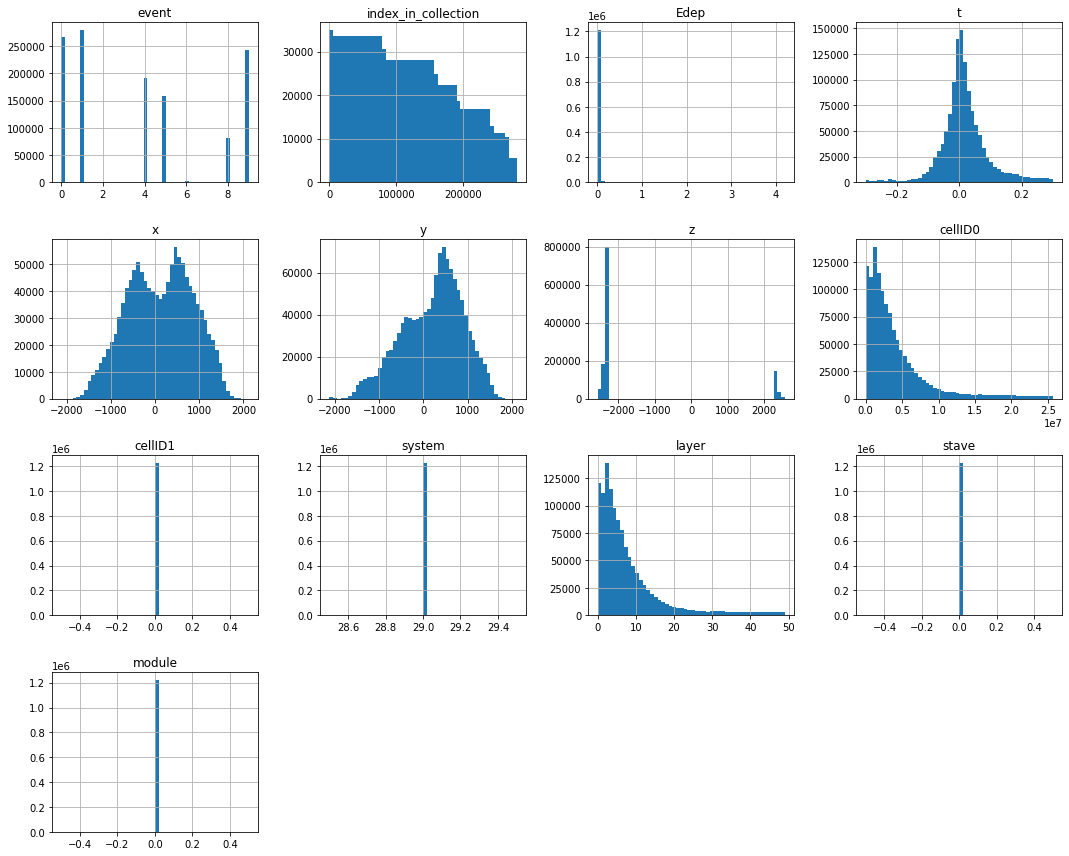

In [14]:
df_ecal_endcap.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import xml.etree.ElementTree as ET

class ECalEndcapMapper:
    def __init__(self, maia_xml, ecal_xml):
        self.maia_xml = maia_xml
        self.ecal_xml = ecal_xml
        self.constants = self._load_constants()
        self._parse_geometry()

    def _load_constants(self):
        # basic units
        mm = 1.0
        cm = 10.0 * mm
        m  = 1000.0 * mm
        deg = np.pi/180
        rad = 1.0
        tesla = 1.0

        tree = ET.parse(self.maia_xml)
        root = tree.getroot()
        consts = {}

        for c in root.findall(".//constant"):
            name = c.attrib.get("name")
            val = c.attrib.get("value")
            type_ = c.attrib.get("type","float")
            if type_ == "string":
                consts[name] = val
            else:
                # safely eval using existing constants
                try:
                    consts[name] = float(eval(val, {"mm": mm, "cm": cm, "m": m, "deg": deg, "rad": rad, "tesla": tesla}, consts))
                except:
                    pass
        return consts

    def _parse_geometry(self):
        c = self.constants
        tree = ET.parse(self.ecal_xml)
        root = tree.getroot()

        # --- z boundaries and layers ---
        self.z_min = c["ECalEndcap_min_z"]
        self.z_max = c["ECalEndcap_max_z"]

        layer_tag = root.find(".//layer")
        self.n_layers = int(layer_tag.attrib.get("repeat",1))
        self.layer_edges = np.linspace(self.z_min, self.z_max, self.n_layers+1)

        # --- stave geometry ---
        plugin_tag = root.find(".//plugin")
        self.n_staves = 12
        self.phi0 = 0.0
        if plugin_tag is not None:
            for arg in plugin_tag.findall("argument"):
                val = arg.attrib.get("value","")
                if "symmetry" in val:
                    # val could be a constant name
                    self.n_staves = int(c.get(val, c.get("ECalEndcap_outer_symmetry",12)))
                elif "phi0" in val:
                    self.phi0 = float(c.get(val,0.0))

        # phi edges of each stave (polygonal)
        self.phi_edges = np.linspace(self.phi0, self.phi0+2*np.pi, self.n_staves+1)

        # --- radial modules (from envelope) ---
        self.modules_r_min = []
        self.modules_r_max = []
        for det in root.findall(".//detector"):
            shape = det.find(".//envelope/shape")
            if shape is not None:
                rmin = shape.attrib.get("rmin", None)
                rmax = shape.attrib.get("rmax", None)
                if rmin and rmax:
                    try:
                        rmin_val = float(eval(rmin, {}, c))
                        rmax_val = float(eval(rmax, {}, c))
                        self.modules_r_min.append(rmin_val)
                        self.modules_r_max.append(rmax_val)
                    except:
                        continue
        if len(self.modules_r_min)==0:
            self.modules_r_min = [c["ECalEndcap_inner_radius"]]
            self.modules_r_max = [c["ECalEndcap_outer_radius"]]

    def locate_position(self, x, y, z):
        """Map a global hit (x,y,z) to (layer, stave, module) respecting polygonal stave"""
        # --- global polar coordinates ---
        r = np.sqrt(x**2 + y**2)
        phi = (np.arctan2(y, x) + 2*np.pi) % (2*np.pi)

        # --- stave index from phi ---
        stave = None
        for i in range(self.n_staves):
            phi_start = self.phi_edges[i]
            phi_end = self.phi_edges[i+1]
            if phi_end < phi_start:
                # wrap-around
                if phi >= phi_start or phi < phi_end:
                    stave = i
                    break
            else:
                if phi_start <= phi < phi_end:
                    stave = i
                    break
        if stave is None:
            stave = 0

        # --- rotate hit into stave-local frame ---
        phi_center = (self.phi_edges[stave] + self.phi_edges[stave+1])/2
        x_local =  np.cos(-phi_center)*x - np.sin(-phi_center)*y
        y_local =  np.sin(-phi_center)*x + np.cos(-phi_center)*y
        r_local = x_local  # along radial direction in stave-local coordinates

        # --- layer along z ---
        z_abs = abs(z)
        layer_idx = np.searchsorted(self.layer_edges, z_abs, side='right') - 1
        layer_idx = np.clip(layer_idx, 0, self.n_layers-1)
        layer = (self.n_layers-1) - layer_idx  # LCIO: outermost layer first

        # --- module along radial direction ---
        module = 0
        for i, (rmin, rmax) in enumerate(zip(self.modules_r_min, self.modules_r_max)):
            if rmin <= r_local <= rmax:
                module = i
                break

        return layer, stave, module

In [33]:
mapper = ECalEndcapMapper("MAIA_v0.xml", "ECalEndcap_o2_v01_02.xml")


tmp = df_ecal_endcap[df_ecal_endcap["layer"] == 13]


for i in [0, 2, 4]:

# Single hit
    layer, stave, module = mapper.locate_position(tmp.iloc[i]["x"], tmp.iloc[i]["y"], tmp.iloc[i]["z"])
    print(layer, stave, module)
    
    print(tmp.iloc[i])
    print()

36 4 0
event                                        0
collection             EcalEndcapCollectionSel
object                    CalorimeterHitIOImpl
index_in_collection                         51
Edep                                  0.012362
t                                     0.000323
x                                  -499.645111
y                                   302.836578
z                                 -2379.550049
cellID0                                6815837
cellID1                                      0
system                                      29
layer                                       13
stave                                        0
module                                       0
Name: 51, dtype: object

36 1 0
event                                        0
collection             EcalEndcapCollectionSel
object                    CalorimeterHitIOImpl
index_in_collection                        235
Edep                                  0.013077
t                    

In [46]:
layers = df_ecal_endcap["z"].to_numpy()
print(len(set(list(layers))))

100


In [38]:



for layer in range(10):
    valid_events = df_ecal_endcap[ df_ecal_endcap["layer"] == layer]
    
    r = (valid_events["x"]**2 + valid_events["y"]**2).to_numpy()
    z = np.abs(valid_events["z"].to_numpy())

    print(layer, np.min(z), np.max(z))

  

0 2310.0 2310.0
1 2315.35009765625 2315.35009765625
2 2320.699951171875 2320.699951171875
3 2326.050048828125 2326.050048828125
4 2331.39990234375 2331.39990234375
5 2336.75 2336.75
6 2342.10009765625 2342.10009765625
7 2347.449951171875 2347.449951171875
8 2352.800048828125 2352.800048828125
9 2358.14990234375 2358.14990234375
